# Homework 9

In [24]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

%matplotlib inline

## 1. Середовище

In [25]:
env = gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array')
state, info = env.reset()

## 2. Додаткові функції

Додаємо візуалізацію `plot_policy_map` з репозиторію https://github.com/SasankYadati/FrozenLake-DP.git

In [26]:
# Допоміжні словники з репозиторію для візуалізації
colors = {
    b'S': 'green',
    b'F': 'skyblue',
    b'H': 'black',
    b'G': 'gold'
}

directions = {
    0: (0, -1), # Left
    1: (1, 0),  # Down
    2: (0, 1),  # Right
    3: (-1, 0)  # Up
}

def plot_policy_map(title, policy, map_desc, colors, directions):
    size = len(map_desc)
    heatmap = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            heatmap[i, j] = 1.0 # Default value for all cells

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_title(title)
    sns.heatmap(heatmap, annot=False, cbar=False, cmap='viridis_r', linewidths=0.5, linecolor='black')

    for i in range(size):
        for j in range(size):
            cell_type = map_desc[i][j]
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color=colors[cell_type], alpha=0.5))

            if cell_type != b'G' and cell_type != b'H':
                action = policy[i * size + j]
                dy, dx = directions[action]
                # Малюємо стрілку
                ax.arrow(j + 0.5, i + 0.5, dx * 0.3, dy * 0.3, 
                         head_width=0.1, head_length=0.1, fc='black', ec='black')

    plt.show()

## 3. Основні функції (Policy & Value Iteration)

In [27]:
def extract_policy(env, value_table, gamma=1.0):
    """
    Формує оптимальну політику на основі заданої таблиці значень станів (value_table) та середовища (env).
    """
    policy = np.zeros(env.observation_space.n)

    for state in range(env.observation_space.n):
        Q_table = np.zeros(env.action_space.n)

        for action in range(env.action_space.n):
            for next_sr in env.unwrapped.P[state][action]:
                trans_prob, next_state, reward_prob, _ = next_sr
                Q_table[action] += (trans_prob * (reward_prob + gamma * value_table[next_state]))
        
        policy[state] = np.argmax(Q_table)

    return policy

In [28]:
def compute_value_function(env, policy, gamma=1.0):
    """
    Обчислює функцію цінності для заданої політики. (Policy Evaluation)
    """
    value_table = np.zeros(env.observation_space.n)
    threshold = 1e-10
    
    while True:
        updated_value_table = np.copy(value_table)

        for state in range(env.observation_space.n):
            # Дія береться з поточної політики
            action = int(policy[state])

            value_table[state] = sum([trans_prob * (reward_prob + gamma * updated_value_table[next_state])
                        for trans_prob, next_state, reward_prob, _ in env.unwrapped.P[state][action]])
        
        if (np.sum((np.fabs(updated_value_table - value_table))) <= threshold):
            break
            
    return value_table

In [29]:
def policy_iteration(env, gamma=1.0, max_iterations=1000):
    """
    Повертає оптимальну політику, функцію цінності, кількість ітерацій та час виконання.
    """
    old_policy = np.zeros(env.observation_space.n)
    start_time = time.time()
    
    for i in range(max_iterations):
        
        # === Крок 1: Оцінка Політики (Policy Evaluation) ===
        new_value_function = compute_value_function(env, old_policy, gamma)
        
        # === Крок 2: Покращення Політики (Policy Improvement) ===
        new_policy = extract_policy(env, new_value_function, gamma)
        
        # === Крок 3: Перевірка збіжності ===
        if (np.all(old_policy == new_policy)):
            total_time = time.time() - start_time
            print(f'Policy-iteration збіглася на ітерації {i+1}.')
            # Повертаємо політику, функцію цінності, ітерації та час
            return new_policy, new_value_function, i+1, total_time
        
        old_policy = new_policy
    
    total_time = time.time() - start_time
    print(f'Policy-iteration досягла макс. ітерацій {max_iterations}.')
    return new_policy, new_value_function, max_iterations, total_time

In [30]:
def value_iteration(env, gamma = 1.0):
    """
    Повертає функцію цінності, кількість ітерацій та час виконання.
    """
    value_table = np.zeros(env.observation_space.n)

    no_of_iterations = 100000
    threshold = 1e-20
    start_time = time.time()

    for i in range(no_of_iterations):
        updated_value_table = np.copy(value_table)

        for state in range(env.observation_space.n):
            Q_value = []
            for action in range(env.action_space.n):
                next_states_rewards = []
                for next_sr in env.unwrapped.P[state][action]:
                    trans_prob, next_state, reward_prob, _ = next_sr
                    next_states_rewards.append((trans_prob * (reward_prob + gamma * updated_value_table[next_state])))
                
                Q_value.append(np.sum(next_states_rewards))

            # Оновлюємо цінність стану максимальним Q-значенням
            value_table[state] = max(Q_value)

        if (np.sum(np.fabs(updated_value_table - value_table)) <= threshold):
            total_time = time.time() - start_time
            print(f'Value-iteration збіглася на ітерації {i+1}.')
            # Повертаємо функцію цінності, ітерації та час
            return value_table, i+1, total_time
    
    total_time = time.time() - start_time
    print(f'Value-iteration досягла макс. ітерацій {no_of_iterations}.')
    return value_table, no_of_iterations, total_time

## 4. Функція для експерименту

In [31]:
# клас Агента

class Agent:
    def __init__(self, policy):
        # Політика - це np.array, де індекс - стан, а значення - дія
        self.policy = policy

    def get_action(self, observation):
        # Просто повертаємо дію з нашої політики для поточного стану
        return int(self.policy[observation])

In [32]:
def run_experiment(env, agent, num_runs=1):
    tot_reward = [0]
    
    for _ in range(num_runs):
        observation, info = env.reset()
        done = False
        reward_per_run = 0
        
        while not done:
            action = agent.get_action(observation)
            observation, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            reward_per_run += reward
        
        tot_reward.append(reward_per_run + tot_reward[-1])
        
    return tot_reward

## 5. Порівняння Методів

In [33]:
gamma = 0.99
N_RUNS = 1000

print("--- Запуск Policy Iteration ---")
policy_pi, v_pi, iters_pi, time_pi = policy_iteration(env, gamma)
agent_pi = Agent(policy_pi) # Створюємо агента 1

print("\n--- Запуск Value Iteration ---")
v_vi, iters_vi, time_vi = value_iteration(env, gamma)
policy_vi = extract_policy(env, v_vi, gamma)
agent_vi = Agent(policy_vi) # Створюємо агента 2

print("\n--- Порівняння Результатів ---")
print(f"Policy Iteration:\n\tІтерацій: {iters_pi}\n\tЧас: {time_pi:.6f} сек")
print(f"Value Iteration:\n\tІтерацій: {iters_vi}\n\tЧас: {time_vi:.6f} сек")

# Перевіряємо, чи політики однакові
policies_equal = np.all(policy_pi == policy_vi)
print(f"\nЧи знайшли алгоритми однакову політику? -> {policies_equal}")

--- Запуск Policy Iteration ---
Policy-iteration збіглася на ітерації 7.

--- Запуск Value Iteration ---
Value-iteration збіглася на ітерації 7.

--- Порівняння Результатів ---
Policy Iteration:
	Ітерацій: 7
	Час: 0.001998 сек
Value Iteration:
	Ітерацій: 7
	Час: 0.002023 сек

Чи знайшли алгоритми однакову політику? -> True


### Візуалізація Знайдених Політик

Розшифровка дій: 0=Вліво (←), 1=Вниз (↓), 2=Вправо (→), 3=Вгору (↑)

--- Оптимальна політика (Policy Iteration) ---
[[1. 2. 1. 0.]
 [1. 0. 1. 0.]
 [2. 1. 1. 0.]
 [0. 2. 2. 0.]]


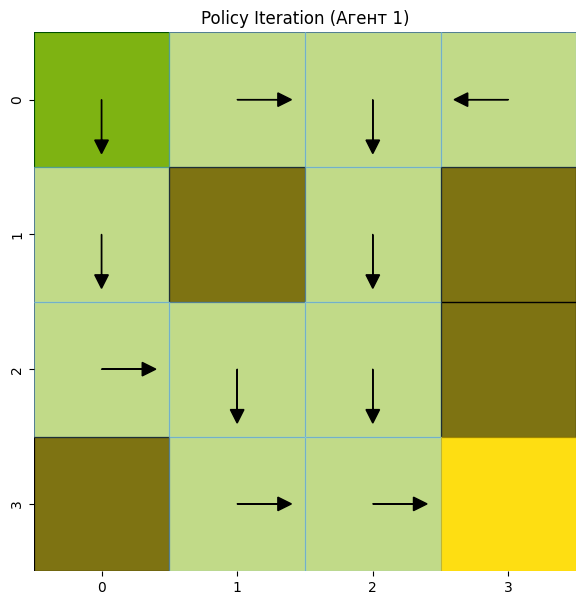


--- Оптимальна політика (Value Iteration) ---
[[1. 2. 1. 0.]
 [1. 0. 1. 0.]
 [2. 1. 1. 0.]
 [0. 2. 2. 0.]]


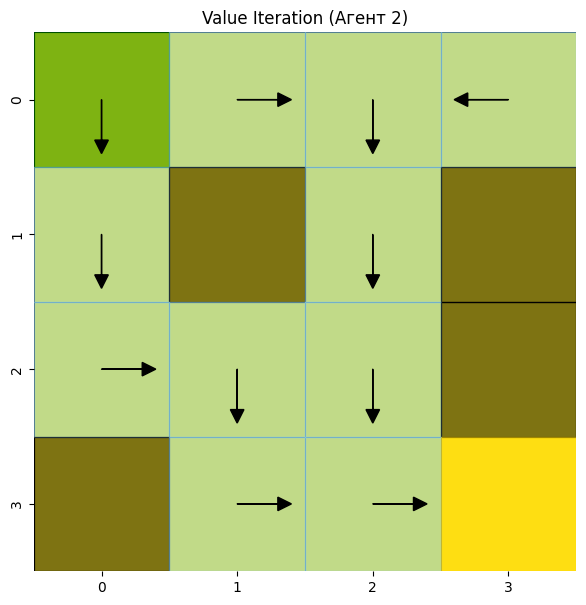

In [34]:
# Отримуємо карту середовища для візуалізації
# `desc` - це опис карти (S, F, H, G)
map_description = env.unwrapped.desc

print("--- Оптимальна політика (Policy Iteration) ---")
print(policy_pi.reshape(4, 4))
plot_policy_map('Policy Iteration (Агент 1)', policy_pi, map_description, colors, directions)

print("\n--- Оптимальна політика (Value Iteration) ---")
print(policy_vi.reshape(4, 4))
plot_policy_map('Value Iteration (Агент 2)', policy_vi, map_description, colors, directions)

### Ілюстрація Порівняння Продуктивності

Запускаємо агентів у середовищі та будуємо графік їхньої сукупної винагороди.

Запуск експерименту на 1000 епізодів для кожного агента...
Побудова графіка...


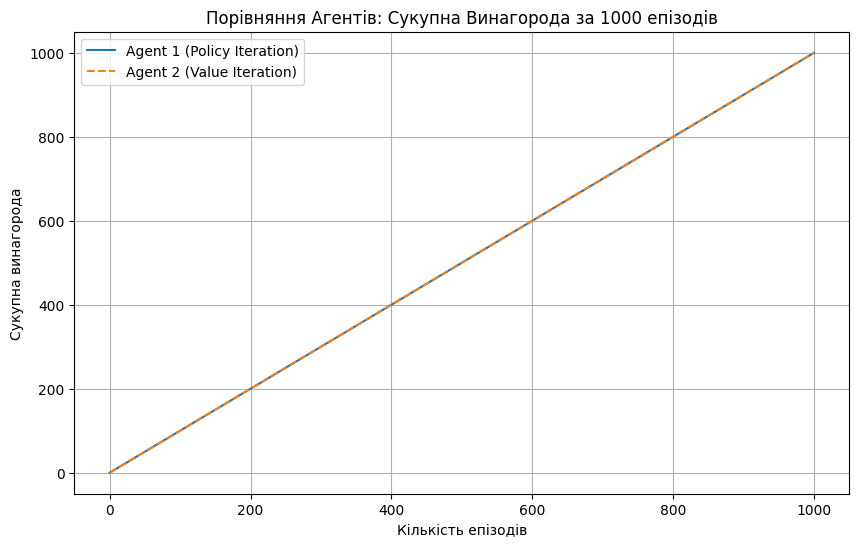


Кінцева сукупна винагорода (Policy Iteration): 1000
Кінцева сукупна винагорода (Value Iteration): 1000


In [35]:
print(f"Запуск експерименту на {N_RUNS} епізодів для кожного агента...")

rewards_pi = run_experiment(env, agent_pi, num_runs=N_RUNS)
rewards_vi = run_experiment(env, agent_vi, num_runs=N_RUNS)

print("Побудова графіка...")

plt.figure(figsize=(10, 6))
plt.plot(rewards_pi, label='Agent 1 (Policy Iteration)')
plt.plot(rewards_vi, label='Agent 2 (Value Iteration)', linestyle='--')
plt.xlabel("Кількість епізодів")
plt.ylabel("Сукупна винагорода")
plt.title(f"Порівняння Агентів: Сукупна Винагорода за {N_RUNS} епізодів")
plt.legend()
plt.grid(True)
plt.show()

print(f"\nКінцева сукупна винагорода (Policy Iteration): {rewards_pi[-1]}")
print(f"Кінцева сукупна винагорода (Value Iteration): {rewards_vi[-1]}")

In [36]:
# Закриття середовища
env.close()

## 6. Деталізований аналіз та бенчмаркінг

--- Теплові карти функцій цінності ---


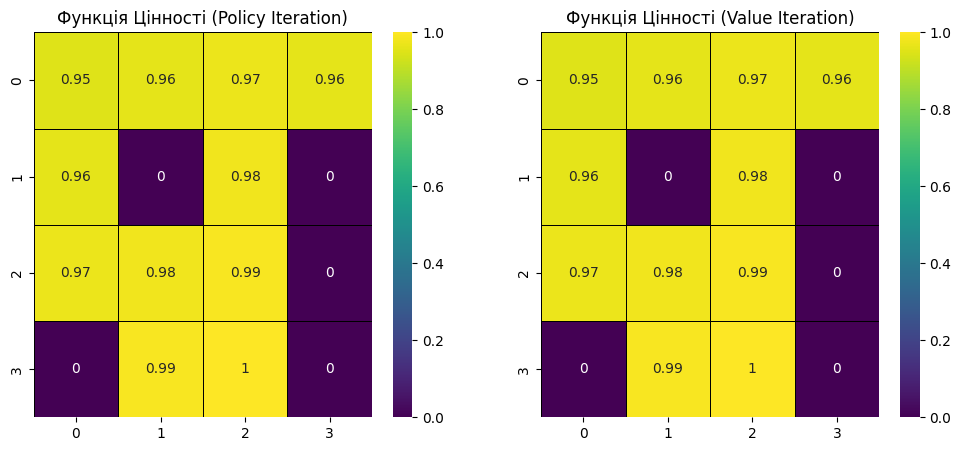


--- Сирі масиви функцій цінності ---
Policy Iteration V(s):
 [0.95099005 0.96059601 0.970299   0.96059601 0.96059601 0.
 0.9801     0.         0.970299   0.9801     0.99       0.
 0.         0.99       1.         0.        ]

Value Iteration V(s):
 [0.95099005 0.96059601 0.970299   0.96059601 0.96059601 0.
 0.9801     0.         0.970299   0.9801     0.99       0.
 0.         0.99       1.         0.        ]


In [37]:
print("--- Теплові карти функцій цінності ---")

v_heatmap_pi = np.reshape(v_pi, (4, 4))
v_heatmap_vi = np.reshape(v_vi, (4, 4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Графік для Policy Iteration
ax1.set_title("Функція Цінності (Policy Iteration)")
sns.heatmap(v_heatmap_pi, annot=True, cbar=True, cmap='viridis', linewidths=0.5, linecolor='black', ax=ax1)

# Графік для Value Iteration
ax2.set_title("Функція Цінності (Value Iteration)")
sns.heatmap(v_heatmap_vi, annot=True, cbar=True, cmap='viridis', linewidths=0.5, linecolor='black', ax=ax2)

plt.show()

print("\n--- Сирі масиви функцій цінності ---")
print("Policy Iteration V(s):\n", v_pi)
print("\nValue Iteration V(s):\n", v_vi)

Запуск покращеного бенчмаркінгу...
Вимірювання для 1 запусків...
Policy-iteration збіглася на ітерації 7.
Value-iteration збіглася на ітерації 7.
Завершено вимірювання для 1 запусків...
Вимірювання для 10 запусків...
Policy-iteration збіглася на ітерації 7.
Policy-iteration збіглася на ітерації 7.
Policy-iteration збіглася на ітерації 7.
Policy-iteration збіглася на ітерації 7.
Policy-iteration збіглася на ітерації 7.
Policy-iteration збіглася на ітерації 7.
Policy-iteration збіглася на ітерації 7.
Policy-iteration збіглася на ітерації 7.
Policy-iteration збіглася на ітерації 7.
Policy-iteration збіглася на ітерації 7.
Value-iteration збіглася на ітерації 7.
Value-iteration збіглася на ітерації 7.
Value-iteration збіглася на ітерації 7.
Value-iteration збіглася на ітерації 7.
Value-iteration збіглася на ітерації 7.
Value-iteration збіглася на ітерації 7.
Value-iteration збіглася на ітерації 7.
Value-iteration збіглася на ітерації 7.
Value-iteration збіглася на ітерації 7.
Value-iterati

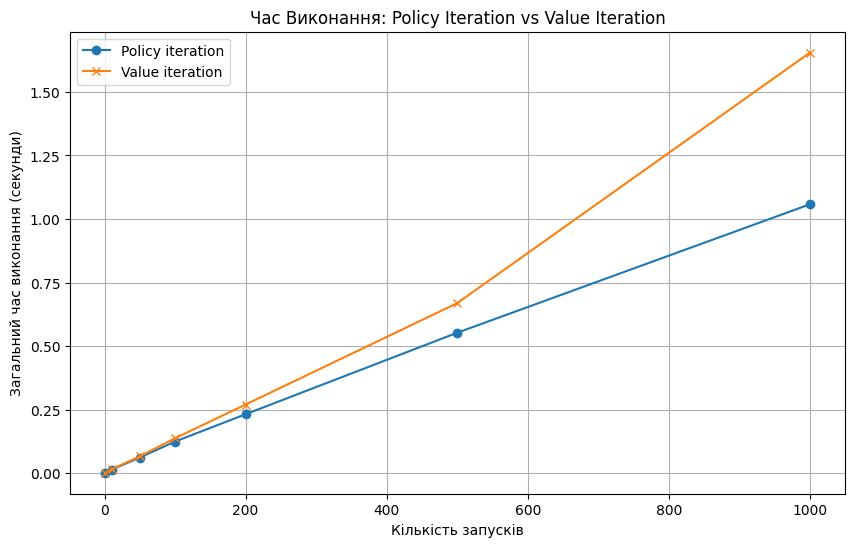

In [38]:
# --- Покращений Бенчмаркінг (Timeit) ---
import timeit

print("Запуск покращеного бенчмаркінгу...")

env = gym.make('FrozenLake-v1', is_slippery=False)
gamma = 0.99

num_runs_options = [1, 10, 50, 100, 200, 500, 1000]
# num_runs_options = [1, 10, 50, 100, 200]
pi_time = []
vi_time = []

for num in num_runs_options:

    print(f"Вимірювання для {num} запусків...")    

    # Вимірюємо Policy Iteration
    pi_callable = lambda: policy_iteration(env, gamma)
    pi_time.append(timeit.timeit(pi_callable, number=num))
    # Вимірюємо Value Iteration
    vi_callable = lambda: value_iteration(env, gamma)
    vi_time.append(timeit.timeit(vi_callable, number=num))

    print(f"Завершено вимірювання для {num} запусків...")

print("Побудова графіка...")
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(num_runs_options, pi_time, label="Policy iteration", marker='o')
ax.plot(num_runs_options, vi_time, label="Value iteration", marker='x')
ax.set_xlabel('Кількість запусків')
ax.set_ylabel('Загальний час виконання (секунди)')
ax.set_title("Час Виконання: Policy Iteration vs Value Iteration")
ax.legend()
ax.grid(True)
plt.show()

In [39]:
print("\n--- Деталізований аналіз Таблиці Ймовірностей P[s][a] ---")

print(f"Кількість станів: {env.observation_space.n}")
print(f"Кількість дій: {env.action_space.n}")

P = env.unwrapped.P

sample_actions = {'LEFT': 0, 'DOWN': 1, 'RIGHT': 2, 'UP': 3}
sample_states = [0, 5, 14] # Стан 0 (початок), 5 (посередині), 14 (перед метою)

print("\n--- Аналіз Таблиці Ймовірностей P[s][a] ---")
print("Формат вихідних даних: [(ймовірність, наступний_стан, винагорода, чи_завершено)]")

for s in sample_states:
    print(f"\n*** Стан {s} ***")
    for a_name, a_idx in sample_actions.items():
        # P[s][a_idx] повертає список можливих переходів
        print(f"  Для дії {a_name} ({a_idx}):")
        print(f"    -> {P[s][a_idx]}")

# Приклад для стану 14
s = 14
a_idx = sample_actions['RIGHT'] # Дія 2 (Вправо)
print(f"\nПриклад переходу до мети (G):")
print(f"  Зі стану {s}, дія 'RIGHT' ({a_idx}):")
print(f"    -> {P[s][a_idx]}")


--- Деталізований аналіз Таблиці Ймовірностей P[s][a] ---
Кількість станів: 16
Кількість дій: 4

--- Аналіз Таблиці Ймовірностей P[s][a] ---
Формат вихідних даних: [(ймовірність, наступний_стан, винагорода, чи_завершено)]

*** Стан 0 ***
  Для дії LEFT (0):
    -> [(1.0, 0, 0, False)]
  Для дії DOWN (1):
    -> [(1.0, 4, 0, False)]
  Для дії RIGHT (2):
    -> [(1.0, 1, 0, False)]
  Для дії UP (3):
    -> [(1.0, 0, 0, False)]

*** Стан 5 ***
  Для дії LEFT (0):
    -> [(1.0, 5, 0, True)]
  Для дії DOWN (1):
    -> [(1.0, 5, 0, True)]
  Для дії RIGHT (2):
    -> [(1.0, 5, 0, True)]
  Для дії UP (3):
    -> [(1.0, 5, 0, True)]

*** Стан 14 ***
  Для дії LEFT (0):
    -> [(1.0, 13, 0, False)]
  Для дії DOWN (1):
    -> [(1.0, 14, 0, False)]
  Для дії RIGHT (2):
    -> [(1.0, 15, 1, True)]
  Для дії UP (3):
    -> [(1.0, 10, 0, False)]

Приклад переходу до мети (G):
  Зі стану 14, дія 'RIGHT' (2):
    -> [(1.0, 15, 1, True)]
